# Revised experiments — Scientific Reports

**Review status (2026-09-30): provisional results; Phase 4B is on hold.** The critical review found four invalid `-9999` pollutant input cells in training, including two primary NO₂ values. Saved model runs are real, but affected training-only validation, fits and downstream results need correction/re-evaluation. The proposed input correction preserves the 23-origin / 3,624-hour scored test mask. No experimental refitting was performed during this review. Read [flow.md](flow.md), [decisions.md](decisions.md), and [the critical review](reports/PHASE4A_CRITICAL_REVIEW.md). The outputs below are preserved pre-correction evidence.

This is the main revision notebook, building on the unchanged original `main.ipynb`.
The same Beijing PM2.5 task, three model families and two updating regimes remain the study’s basis. Supporting modules make corrections and results reproducible.

## Phase 1 — Data audit and correctness

Reports and artifacts are generated under `revision/`. Bounded pilots are feasibility checks, not final comparisons.


In [1]:
from pathlib import Path
import subprocess, sys, os
root = Path.cwd()
if not (root / "main.ipynb").exists():
    root = next(p for p in root.parents if (p / "main.ipynb").exists())
python = str(root / "venv/bin/python") if (root / "venv/bin/python").exists() else sys.executable
env = os.environ.copy()
for name in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    env[name] = "2"
env["MPLCONFIGDIR"] = "/tmp/weather-revision-matplotlib"
def run(*args):
    return subprocess.run([python, *args], cwd=root, env=env, check=True)


In [2]:
run("-m", "revision.code.audit")


Out[2]: CompletedProcess(args=['/home/moazzam/Documents/Windows/VS Code/Python/Research/Weather Forecasting - Experiments/venv/bin/python', '-m', 'revision.code.audit'], returncode=0)
{
  "raw_rows": 39523,
  "raw_missing_values": 0,
  "calendar_hours": 40267,
  "missing_hours": 744,
  "gap_intervals": 21,
  "training_calendar_hours": 36240,
  "training_observed_targets": 35736,
  "test_calendar_hours": 4027,
  "test_observed_targets": 3787,
  "full_test_windows": 23,
  "eligible_test_windows": 16,
  "evaluated_hours": 2688,
  "tail_hours": 163,
  "preprocessed_rows": 36830,
  "removed_original_rows": 2693,
  "preprocessed_matches_notebook_global_zscore_filter": true
}
Eligible test windows: [1, 2, 3, 4, 5, 6, 7, 10, 16, 17, 18, 19, 20, 21, 22, 23]


 *** This program and the respective minimum Redundancy Maximum Relevance (mRMR) 
     algorithm were developed by Hanchuan Peng <hanchuan.peng@gmail.com>for
     the paper 
     "Feature selection based on mutual information: criteria of 

In [3]:
run("-m", "unittest", "discover", "-s", "revision/tests", "-v")


Out[3]: CompletedProcess(args=['/home/moazzam/Documents/Windows/VS Code/Python/Research/Weather Forecasting - Experiments/venv/bin/python', '-m', 'unittest', 'discover', '-s', 'revision/tests', '-v'], returncode=0)
test_cross_horizon_placeholder_effect_is_rejected (test_coverage.CoverageTests.test_cross_horizon_placeholder_effect_is_rejected) ... ok
test_fill_preserves_observations_and_is_prefix_causal (test_coverage.CoverageTests.test_fill_preserves_observations_and_is_prefix_causal) ... ok
test_installed_neural_future_placeholders_do_not_affect_other_leads (test_coverage.CoverageTests.test_installed_neural_future_placeholders_do_not_affect_other_leads) ... Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
WARNING - (py.warnings._showwarnmsg) - /home/moazzam/Documents/Windows/VS Code/Python/Research/Weather Forecasting - Experiments/venv/lib/python3.11/site-packages/neuralprophet/df_utils.py:464: FutureWarning: DataFram

## Installed-library checks and feasibility pilots

Run only after reviewing the data audit and protocol. These may take several minutes. Pilot predictions are training-only validation forecasts and must not be presented as final model comparisons.


In [4]:
# run("-m", "revision.code.model_checks")
# run("-m", "revision.code.pilots")


In [5]:
import pandas as pd
windows = pd.read_csv(root / "revision/artifacts/phase1/test_windows.csv")
windows


Out[5]: 
    window  ...                                          exclusion
0        1  ...                                                NaN
1        2  ...                                                NaN
2        3  ...                                                NaN
3        4  ...                                                NaN
4        5  ...                                                NaN
5        6  ...                                                NaN
6        7  ...                                                NaN
7        8  ...             missing_future_target_or_PP_covariates
8        9  ...                                    missing_context
9       10  ...                                                NaN
10      11  ...             missing_future_target_or_PP_covariates
11      12  ...  missing_context;missing_future_target_or_PP_co...
12      13  ...                                    missing_context
13      14  ...             missing_future_target_or_

## Phase 2 — Preserved strict-availability reference

The experiments run through `revision.code.phase2_runner` in isolated, sequential processes. Moazzam does not need to execute this notebook. The runner checkpoints each valid forecast origin; the saved CSV and JSON files below are the evidence used for the paper and response. `main.ipynb` remains untouched.

First, four complete validation weeks inside the training period screen four SARIMAX orders, two Prophet seasonality modes, and two NeuralProphet epoch counts. Only the selected settings go into the held-out comparison. The held-out evaluation uses 16 complete, matched weeks (2,688 hours). Refit and frozen runs, persistence baselines, seed repeats, predictor ablations, clipping sensitivity, and EWMA alternatives share the established calendar and information set.

The following commands are managed and run by the revision workflow; this notebook reads their artifacts after completion:

```bash
venv/bin/python -m revision.code.phase2_runner validate
venv/bin/python -m revision.code.phase2_runner baselines
venv/bin/python -m revision.code.phase2_runner core
venv/bin/python -m revision.code.phase2_runner ablate
venv/bin/python -m revision.code.phase2_runner correct
venv/bin/python -m revision.code.phase2_recover
venv/bin/python -m revision.code.phase2_summary
venv/bin/python -m revision.code.phase2_status
```

Validation must complete before `core` or `ablate`. Repeating a command skips completed tasks whose protocol/code signature matches. Check `artifacts/phase2/supervisor.jsonl` and each task's `metadata.json` and `run.log` for failures before interpreting a table.

Training-only validation is complete: SARIMAX `(1,0,1) × (1,0,1,24)`, additive Prophet and 50-epoch NeuralProphet were selected. Three of four SARIMAX candidates converged; the failed candidate is preserved in its metadata. The scheduled held-out matrix has finished. Separately recorded numerical recoveries address nonconverged SARIMAX fits without changing selected model settings or information sets. The verification cell below reports current accepted coverage. Original failed attempts remain in the audit trail.


In [6]:
import json
phase2 = root / "revision/artifacts/phase2"
selection_file = phase2 / "selection.json"
if selection_file.exists():
    selected = json.loads(selection_file.read_text())
    display(pd.DataFrame([{"family": family, **candidate} for family, candidate in selected["selected"].items()]))
else:
    print("Training-only validation is still running; no model settings are selected yet.")


,family,order,seasonal_order,seasonality_mode,epochs
0,sarimax,"[1, 0, 1]","[1, 0, 1, 24]",NaN,NaN
1,prophet,NaN,NaN,additive,NaN
2,neuralprophet,NaN,NaN,NaN,50.0


In [7]:
from pathlib import Path
runs = phase2 / "runs"
records = []
for metadata_file in sorted(runs.glob("*/metadata.json")) if runs.exists() else []:
    record = json.loads(metadata_file.read_text())
    task = record["task"]
    records.append({"run_id":task["id"],"stage":task["stage"],"family":task["family"],
                    "status":record.get("status"),"scored_hours":record.get("scored_hours"),
                    "mean_weekly_mae":record.get("mean_weekly_mae"),
                    "pooled_rmse":record.get("pooled_rmse")})
display(pd.DataFrame(records))


,run_id,stage,family,status,scored_hours,mean_weekly_mae,pooled_rmse
0,ablate_neuralprophet_broad,ablate,neuralprophet,completed,2688.0,20.868162,28.780764
1,ablate_neuralprophet_clip,ablate,neuralprophet,completed,2688.0,60.012240,78.662211
2,ablate_neuralprophet_no_inputs,ablate,neuralprophet,completed,2688.0,127.462355,192.971240
3,ablate_prophet_broad,ablate,prophet,completed,2688.0,19.923080,26.648186
4,ablate_prophet_clip,ablate,prophet,completed,2688.0,48.279714,64.632300
...,...,...,...,...,...,...,...
103,validate_prophet_1,validate,prophet,completed,672.0,41.500746,56.988164
104,validate_sarimax_0,validate,sarimax,completed,672.0,15.024757,22.369720
105,validate_sarimax_1,validate,sarimax,failed,NaN,NaN,NaN
106,validate_sarimax_2,validate,sarimax,completed,672.0,38.941065,58.326836


## Verified strict-reference evidence and descriptive results

The coverage mapping names the exact original or recovered forecast used for each planned task. Convergence, calendar/lead alignment, observed targets, correction timing, and original-file checksums are checked by `revision.code.phase2_verify`. Numerical recoveries retain their own provenance and resource records.

These are descriptive point estimates. Phase 3 will provide paired uncertainty, lead-time diagnostics, residual analysis, seed variability, and publication figures. The manuscript and point-by-point response are still pending.


In [8]:
verification = json.loads((phase2 / "verification.json").read_text())
print(json.dumps({key: verification[key] for key in [
    "complete_tasks", "expected_core_ablation_tasks", "recovered_tasks",
    "unresolved_failed_tasks", "integrity_errors", "validation_completed",
    "validation_failures", "baselines", "correction_streams", "original_files_verified"
]}, indent=2))
coverage = pd.read_csv(phase2 / "verified_coverage.csv")
display(coverage.groupby(["family", "regime", "variant", "seed"])[["windows", "hours", "recovered_windows"]].sum())


{
  "complete_tasks": 94,
  "expected_core_ablation_tasks": 94,
  "recovered_tasks": 6,
  "unresolved_failed_tasks": 0,
  "integrity_errors": [],
  "validation_completed": 7,
  "validation_failures": [
    "validate_sarimax_1"
  ],
  "baselines": 3,
  "correction_streams": 35,
  "original_files_verified": 21
}


windows  hours  recovered_windows
family        regime variant   seed                                   
neuralprophet frozen broad     42         16   2688                  0
                     clip      42         16   2688                  0
                     no_inputs 42         16   2688                  0
                     selected  42         16   2688                  0
                               123        16   2688                  0
                               2026       16   2688                  0
              walk   selected  42         16   2688                  0
                               123        16   2688                  0
                               2026       16   2688                  0
prophet       frozen broad     42         16   2688                  0
                     clip      42         16   2688                  0
                     no_inputs 42         16   2688                  0
                     selected  42         16   2688                  0
              walk   selected  42         16   2688                  0
sarimax       frozen broad     42         16   2688                  0
                     clip      42         16   2688                 16
                     no_inputs 42         16   2688                  0
                     selected  42         16   2688                  0
              walk   selected  42         16   2688                  5

In [9]:
metrics = pd.read_csv(phase2 / "experimental_summary.csv")
display(metrics[metrics.variant.eq("selected")])


,family,regime,variant,seed,recovered_windows,windows,hours,pooled_mae,pooled_rmse,mean_weekly_mae,weekly_mae_sd,mean_weekly_rmse,weekly_rmse_sd
3,neuralprophet,frozen,selected,42,0,16,2688,38.442519,54.157017,38.442519,18.560054,48.934618,23.964100
4,neuralprophet,frozen,selected,123,0,16,2688,40.701115,55.787384,40.701115,17.572055,51.358198,22.499014
5,neuralprophet,frozen,selected,2026,0,16,2688,34.456326,47.357530,34.456326,13.556378,43.778159,18.653569
6,neuralprophet,walk,selected,42,0,16,2688,34.224598,48.929429,34.224598,14.612986,44.298301,21.460030
7,neuralprophet,walk,selected,123,0,16,2688,36.039326,50.488805,36.039326,13.966784,46.460927,20.409193
8,neuralprophet,walk,selected,2026,0,16,2688,34.250126,47.300391,34.250126,13.693926,43.613797,18.907880
12,prophet,frozen,selected,42,0,16,2688,36.963392,49.281056,36.963392,12.948512,46.531975,16.761791
13,prophet,walk,selected,42,0,16,2688,35.497585,48.594115,35.497585,12.453394,45.621826,17.283117
17,sarimax,frozen,selected,42,0,16,2688,29.914284,47.541491,29.914284,17.300945,40.733084,25.319488
18,sarimax,walk,selected,42,5,16,2688,29.877627,47.505589,29.877627,17.295168,40.679786,25.339002


In [10]:
display(metrics[metrics.regime.eq("frozen") & metrics.seed.eq(42)])


,family,regime,variant,seed,recovered_windows,windows,hours,pooled_mae,pooled_rmse,mean_weekly_mae,weekly_mae_sd,mean_weekly_rmse,weekly_rmse_sd
0,neuralprophet,frozen,broad,42,0,16,2688,20.868162,28.780764,20.868162,5.879963,27.177300,9.783073
1,neuralprophet,frozen,clip,42,0,16,2688,60.012240,78.662211,60.012240,32.119543,72.091776,32.504675
2,neuralprophet,frozen,no_inputs,42,0,16,2688,127.462355,192.971240,127.462355,102.995697,152.731490,121.812934
3,neuralprophet,frozen,selected,42,0,16,2688,38.442519,54.157017,38.442519,18.560054,48.934618,23.964100
9,prophet,frozen,broad,42,0,16,2688,19.923080,26.648186,19.923080,6.171178,25.488139,8.031975
10,prophet,frozen,clip,42,0,16,2688,48.279714,64.632300,48.279714,17.691605,61.242370,21.334325
11,prophet,frozen,no_inputs,42,0,16,2688,146.841107,208.317071,146.841107,99.162261,174.757483,117.102002
12,prophet,frozen,selected,42,0,16,2688,36.963392,49.281056,36.963392,12.948512,46.531975,16.761791
14,sarimax,frozen,broad,42,0,16,2688,17.572708,24.426489,17.572708,5.517022,22.896743,8.787418
15,sarimax,frozen,clip,42,16,16,2688,32.654833,52.168174,32.654833,16.128050,46.123453,25.174494


In [11]:
display(pd.read_csv(phase2 / "baseline_summary.csv"))
correction = pd.read_csv(phase2 / "corrections/summary.csv")
display(correction[correction.alpha.isin([0., 0.3, 1.])])


,run,windows,hours,mean_weekly_mae,weekly_mae_sd,pooled_rmse
0,daily_persistence,16,2688,131.184461,117.025894,222.425082
1,persistence,16,2688,125.372671,108.134489,203.799541
2,weekly_persistence,16,2688,164.586462,132.046347,268.420651


,run_id,alpha,mean_weekly_mae,pooled_rmse
0,core_sarimax_frozen_s42,0.0,29.914284,47.541491
3,core_sarimax_frozen_s42,0.3,29.478728,45.274477
6,core_sarimax_frozen_s42,1.0,33.077341,48.675804
7,core_prophet_frozen_s42,0.0,36.963392,49.281056
10,core_prophet_frozen_s42,0.3,35.743806,48.771906
13,core_prophet_frozen_s42,1.0,36.809893,49.235660
14,core_neuralprophet_frozen_s42,0.0,38.442519,54.157017
17,core_neuralprophet_frozen_s42,0.3,33.302983,48.054795
20,core_neuralprophet_frozen_s42,1.0,33.167404,47.527849
21,core_neuralprophet_frozen_s123,0.0,40.701115,55.787384


## Coverage reconsideration before Phase 3

Moazzam requested continuity with the 23-week calendar schedule. The broader protocol retains all 23 origins and scores only original target hours with observed PP covariates: 3,624 of 3,864 scheduled hours, comprising 19 fully observed weeks and four partial weeks. The final 163-hour remainder remains separately reported.

Training data policies and validation-selected configurations remain unchanged. NeuralProphet inference context and baseline histories use an explicit past-only seasonal fill where needed; fitting/scoring targets remain original. Missing future-input timestamps are excluded from scoring, and scored predictions must be invariant to computational placeholders at those timestamps. Each frozen stream reproduces the strict 16-week base forecasts; compatible weekly fits are reused with provenance.

The 16-week experiment above remains the strict sensitivity. Broader EWMA streams update on observed residuals after every scheduled week, so corrected predictions on the strict subset can differ from the old skip/carry policy. Mean weekly errors and pooled hourly errors now have different weights because four weeks have fewer scored hours. Phase 3 remains pending until the broader verification passes.


In [12]:
broader = root / "revision/artifacts/coverage_reconsideration"
display(pd.read_csv(broader / "windows.csv"))
display(pd.read_csv(broader / "history_fill_validation.csv"))
print("Historical reconstruction is an assumption; these training-only checks were not used to choose the fill method.")


Historical reconstruction is an assumption; these training-only checks were not used to choose the fill method.


,window,position,origin,last_target,calendar_hours,scored_hours,missing_context_target_hours,missing_context_input_hours,full_week,full_observed_week,strict_eligible
0,1,36240,2025-01-13 01:00:00,2025-01-20 00:00:00,168,168,0,0,True,True,True
1,2,36408,2025-01-20 01:00:00,2025-01-27 00:00:00,168,168,0,0,True,True,True
2,3,36576,2025-01-27 01:00:00,2025-02-03 00:00:00,168,168,0,0,True,True,True
3,4,36744,2025-02-03 01:00:00,2025-02-10 00:00:00,168,168,0,0,True,True,True
4,5,36912,2025-02-10 01:00:00,2025-02-17 00:00:00,168,168,0,0,True,True,True
5,6,37080,2025-02-17 01:00:00,2025-02-24 00:00:00,168,168,0,0,True,True,True
6,7,37248,2025-02-24 01:00:00,2025-03-03 00:00:00,168,168,0,0,True,True,True
7,8,37416,2025-03-03 01:00:00,2025-03-10 00:00:00,168,120,0,0,True,False,False
8,9,37584,2025-03-10 01:00:00,2025-03-17 00:00:00,168,168,48,48,True,True,False
9,10,37752,2025-03-17 01:00:00,2025-03-24 00:00:00,168,168,0,0,True,True,True


,validation_origin,masked_history_hours,reconstruction_mae,reconstruction_rmse,used_for_method_selection
0,2024-12-16 01:00:00,24,147.337500,167.823533,False
1,2024-12-16 01:00:00,48,110.661250,158.947866,False
2,2024-12-16 01:00:00,120,270.506500,373.502286,False
3,2024-12-23 01:00:00,24,158.659583,163.056605,False
4,2024-12-23 01:00:00,48,136.450000,166.099829,False
5,2024-12-23 01:00:00,120,214.481167,286.701771,False
6,2024-12-30 01:00:00,24,286.547083,323.591065,False
7,2024-12-30 01:00:00,48,294.256458,336.003626,False
8,2024-12-30 01:00:00,120,360.379917,464.092897,False
9,2025-01-06 01:00:00,24,432.785000,515.810775,False


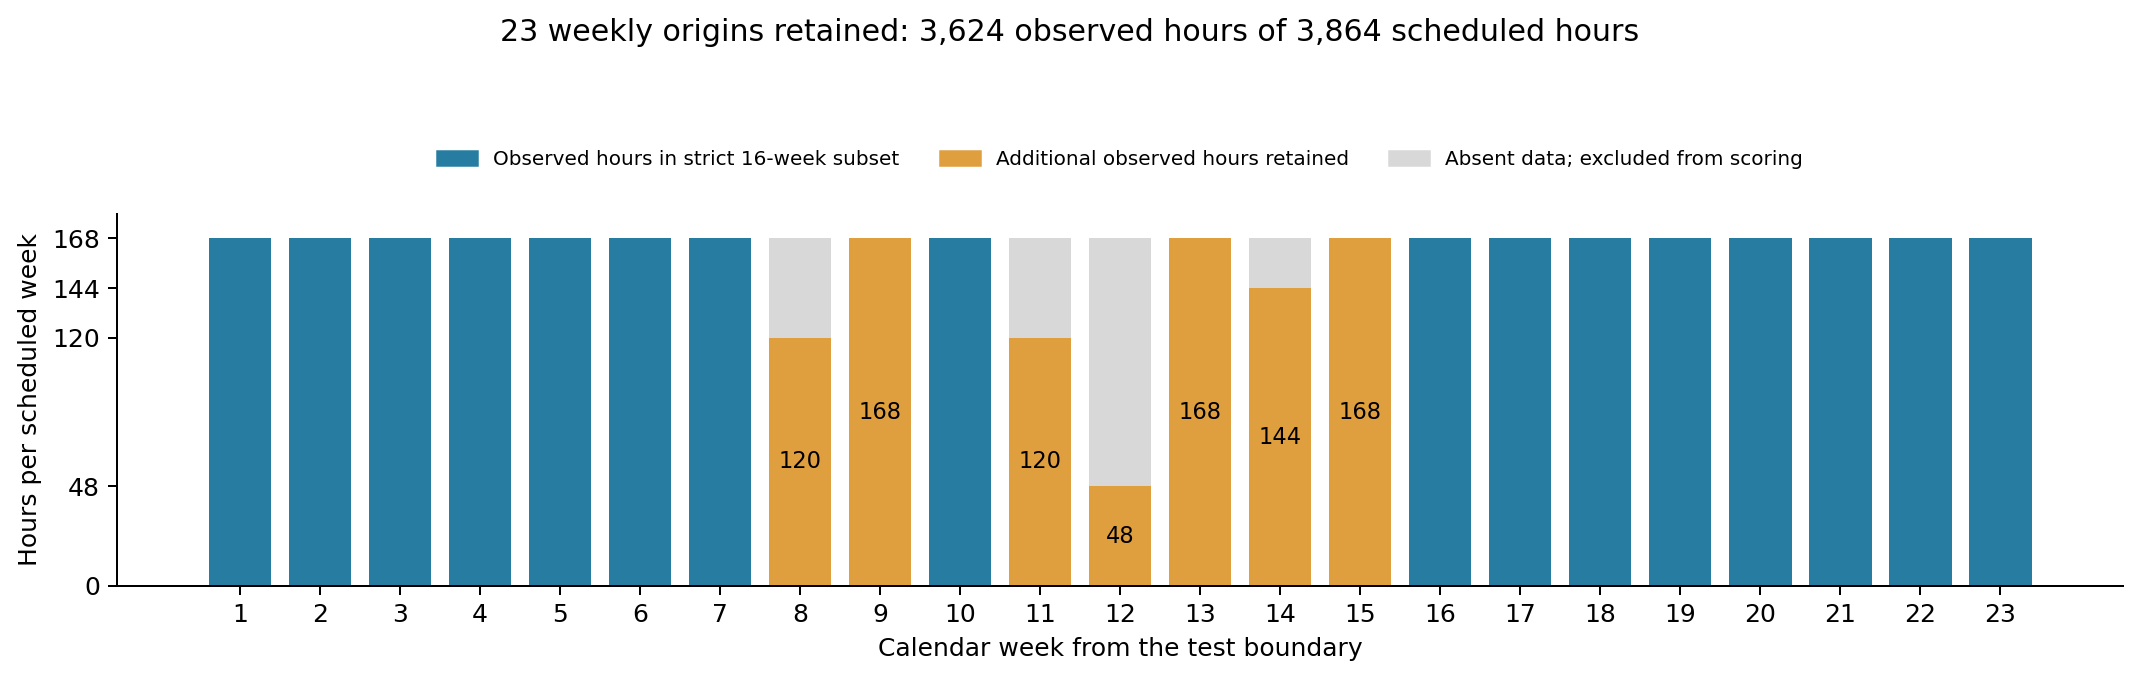

In [13]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
coverage_table = pd.read_csv(broader / "windows.csv")
full_weeks = coverage_table[coverage_table.full_week]
colors = ["#277da1" if strict else "#e09f3e" for strict in full_weeks.strict_eligible]
fig, ax = plt.subplots(figsize=(12, 3.7))
ax.bar(full_weeks.window, full_weeks.scored_hours, color=colors, width=0.78)
ax.bar(full_weeks.window, 168-full_weeks.scored_hours, bottom=full_weeks.scored_hours,
       color="#d8d8d8", width=0.78)
for row in full_weeks.itertuples():
    if not row.strict_eligible:
        ax.text(row.window, row.scored_hours/2, str(row.scored_hours), ha="center", va="center", fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#277da1", label="Observed hours in strict 16-week subset"),
                   Patch(color="#e09f3e", label="Additional observed hours retained"),
                   Patch(color="#d8d8d8", label="Absent data; excluded from scoring")],
          loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=3, frameon=False, fontsize=8)
ax.set(xticks=range(1,24), yticks=[0,48,120,144,168], ylim=(0,180),
       xlabel="Calendar week from the test boundary", ylabel="Hours per scheduled week")
ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("23 weekly origins retained: 3,624 observed hours of 3,864 scheduled hours", y=1.01)
fig.tight_layout()
fig.savefig(broader / "coverage.png", dpi=180, bbox_inches="tight")
fig.savefig(broader / "coverage.pdf", bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(broader / "coverage.png")))


In [14]:
broader_verification = json.loads((broader / "verification.json").read_text())
print(json.dumps({key: broader_verification[key] for key in [
    "ready", "complete_tasks", "expected_tasks", "scheduled_weeks", "scheduled_hours",
    "observed_scoring_hours", "full_observed_weeks", "partially_observed_weeks", "integrity_errors"
]}, indent=2))
if not broader_verification["ready"]:
    print("Broader experiments are still in progress; current tables are provisional.")
broader_metrics = pd.read_csv(broader / "experimental_summary.csv")
display(broader_metrics[broader_metrics.variant.eq("selected")])


{
  "ready": true,
  "complete_tasks": 129,
  "expected_tasks": 129,
  "scheduled_weeks": 23,
  "scheduled_hours": 3864,
  "observed_scoring_hours": 3624,
  "full_observed_weeks": 19,
  "partially_observed_weeks": 4,
  "integrity_errors": []
}


,family,regime,variant,seed,windows,hours,pooled_mae,pooled_rmse,mean_weekly_mae,weekly_mae_sd,mean_weekly_rmse,weekly_rmse_sd,strict_subset_pooled_mae
3,neuralprophet,frozen,selected,42,23,3624,38.462151,52.783788,38.916842,16.073036,48.926171,20.462310,38.442519
4,neuralprophet,frozen,selected,123,23,3624,39.979215,54.271596,40.305559,15.277589,50.819498,19.378688,40.701115
5,neuralprophet,frozen,selected,2026,23,3624,34.803778,47.053868,35.299659,12.985873,44.383189,16.740839,34.456326
6,neuralprophet,walk,selected,42,23,3624,35.282708,48.880451,35.886656,13.181618,45.667479,18.572108,34.224598
7,neuralprophet,walk,selected,123,23,3624,36.583191,50.329427,37.109965,12.551822,47.455674,17.749141,36.039326
8,neuralprophet,walk,selected,2026,23,3624,34.583840,46.958352,35.075009,13.202750,44.174655,17.011832,34.250126
12,prophet,frozen,selected,42,23,3624,38.648271,49.728723,39.464362,12.938926,48.152496,15.312704,36.963392
13,prophet,walk,selected,42,23,3624,36.162997,48.606108,36.276992,11.317011,45.994920,15.384038,35.497585
17,sarimax,frozen,selected,42,23,3624,30.504256,47.428948,30.618100,15.358295,41.944385,22.332522,29.914284
18,sarimax,walk,selected,42,23,3624,30.442960,47.348583,30.548577,15.305416,41.844215,22.302672,29.877627


In [15]:
display(broader_metrics[broader_metrics.regime.eq("frozen") & broader_metrics.seed.eq(42)])
display(pd.read_csv(broader / "baseline_summary.csv"))
broader_correction = pd.read_csv(broader / "corrections/summary.csv")
display(broader_correction[broader_correction.alpha.isin([0., 0.3, 1.])])


,family,regime,variant,seed,windows,hours,pooled_mae,pooled_rmse,mean_weekly_mae,weekly_mae_sd,mean_weekly_rmse,weekly_rmse_sd,strict_subset_pooled_mae
0,neuralprophet,frozen,broad,42,23,3624,21.563123,30.750060,22.362275,7.686166,29.817248,10.739952,20.868162
1,neuralprophet,frozen,clip,42,23,3624,57.531475,75.024404,57.160615,27.389656,69.148036,27.866074,60.012240
2,neuralprophet,frozen,no_inputs,42,23,3624,119.499321,177.023466,117.141061,87.603084,140.173634,104.190157,127.462355
3,neuralprophet,frozen,selected,42,23,3624,38.462151,52.783788,38.916842,16.073036,48.926171,20.462310,38.442519
9,prophet,frozen,broad,42,23,3624,19.895824,26.704514,19.651543,5.624857,25.358247,7.294655,19.923080
10,prophet,frozen,clip,42,23,3624,47.266816,62.264179,47.424689,15.323950,59.535923,18.522846,48.279714
11,prophet,frozen,no_inputs,42,23,3624,134.066578,190.395510,130.954366,86.809438,156.936973,102.378368,146.841107
12,prophet,frozen,selected,42,23,3624,38.648271,49.728723,39.464362,12.938926,48.152496,15.312704,36.963392
14,sarimax,frozen,broad,42,23,3624,17.591015,24.521470,17.451456,5.197346,22.896426,8.055401,17.572708
15,sarimax,frozen,clip,42,23,3624,33.168911,51.572043,33.253629,14.409251,46.509831,22.066645,32.654833


,run,windows,hours,pooled_mae,pooled_rmse,mean_weekly_mae,weekly_mae_sd,mean_weekly_rmse,weekly_rmse_sd
0,persistence,23,3624,125.737715,198.326604,127.776939,106.391866,157.234076,123.993455
1,daily_persistence,23,3624,121.521371,202.341098,119.528253,102.208795,153.618692,127.937435
2,weekly_persistence,23,3624,152.903093,248.646707,149.812053,119.293039,193.492104,151.154316


,run_id,alpha,windows,hours,pooled_mae,pooled_rmse,mean_weekly_mae,weekly_mae_sd,mean_weekly_rmse,weekly_rmse_sd
0,core_sarimax_frozen_s42,0.0,23,3624,30.504256,47.428948,30.618100,15.358295,41.944385,22.332522
3,core_sarimax_frozen_s42,0.3,23,3624,30.154644,44.297887,30.336208,13.381810,39.843765,19.537854
6,core_sarimax_frozen_s42,1.0,23,3624,31.222054,45.439157,31.594093,15.545925,40.801318,21.405518
7,core_prophet_frozen_s42,0.0,23,3624,38.648271,49.728723,39.464362,12.938926,48.152496,15.312704
10,core_prophet_frozen_s42,0.3,23,3624,35.624305,47.593702,35.873571,10.906898,45.282475,14.693515
13,core_prophet_frozen_s42,1.0,23,3624,34.660461,46.533547,34.946974,12.155508,43.888986,16.018693
14,core_neuralprophet_frozen_s42,0.0,23,3624,38.462151,52.783788,38.916842,16.073036,48.926171,20.462310
17,core_neuralprophet_frozen_s42,0.3,23,3624,34.046416,47.567101,34.604036,11.744531,44.575660,17.527875
20,core_neuralprophet_frozen_s42,1.0,23,3624,32.126371,45.397050,32.673816,12.580704,42.193681,17.980798
21,core_neuralprophet_frozen_s123,0.0,23,3624,39.979215,54.271596,40.305559,15.277589,50.819498,19.378688


## Phase 3 — Publication analysis

This section regenerates tables and PDF/PNG figures from verified saved 23-origin forecasts. It does not refit models or choose parameters from test errors. All comparisons use the shared 3,624-observed-hour mask; the original strict 16-week evaluation is an explicit sensitivity. The generated report explains paired week-block uncertainty, extremes, coefficients and resource boundaries.


In [16]:
run("-m", "revision.code.phase3_analysis")


Out[16]: CompletedProcess(args=['/home/moazzam/Documents/Windows/VS Code/Python/Research/Weather Forecasting - Experiments/venv/bin/python', '-m', 'revision.code.phase3_analysis'], returncode=0)
{
  "source_protocol_signature": "f1b785fcfd49bf50207714991659a0525b71ebbfb2b0f88d8ff0985494af6cdd",
  "streams": 27,
  "paired_contrasts": 11,
  "training_q95_threshold": 691.335,
  "high_hours": 158,
  "figure_stems": [
    "lead_hour_mae",
    "lead_day_mae",
    "weekly_mae_chronology",
    "weekly_mae_distribution",
    "correction_diagnostics"
  ]
}


In [17]:
phase3 = root / "revision/artifacts/phase3"
phase3_metrics = pd.read_csv(phase3 / "performance.csv")
display(phase3_metrics[phase3_metrics.stream.str.contains("s42|persistence")][["stream", "windows", "hours", "pooled_mae", "pooled_rmse", "mean_weekly_mae", "weekly_mae_sd"]])
display(pd.read_csv(phase3 / "paired_contrasts.csv"))
display(pd.read_csv(phase3 / "high_concentration.csv").query("stream in ['sarimax_frozen_s42', 'prophet_frozen_s42', 'neuralprophet_frozen_s42']"))


,stream,windows,hours,pooled_mae,pooled_rmse,mean_weekly_mae,weekly_mae_sd
0,sarimax_frozen_s42,23,3624,30.504256,47.428948,30.618100,15.358295
1,sarimax_walk_s42,23,3624,30.442960,47.348583,30.548577,15.305416
2,sarimax_frozen_s42_ewma03,23,3624,30.154644,44.297887,30.336208,13.381810
3,prophet_frozen_s42,23,3624,38.648271,49.728723,39.464362,12.938926
4,prophet_walk_s42,23,3624,36.162997,48.606108,36.276992,11.317011
5,prophet_frozen_s42_ewma03,23,3624,35.624305,47.593702,35.873571,10.906898
6,neuralprophet_frozen_s42,23,3624,38.462151,52.783788,38.916842,16.073036
7,neuralprophet_walk_s42,23,3624,35.282708,48.880451,35.886656,13.181618
8,neuralprophet_frozen_s42_ewma03,23,3624,34.046416,47.567101,34.604036,11.744531
15,persistence,23,3624,125.737715,198.326604,127.776939,106.391866


,contrast,weeks,mean_weekly_mae_difference,weekly_difference_sd,ci95_block2_low,ci95_block2_high,ci95_block3_low,ci95_block3_high,ci95_block4_low,ci95_block4_high
0,sarimax: EWMA 0.3 − base,23,-0.281892,6.374242,-3.409129,2.547473,-3.766870,2.656072,-3.773953,2.547619
1,prophet: EWMA 0.3 − base,23,-3.590791,8.552794,-8.292738,-0.576702,-9.106438,-0.236060,-9.329798,-0.388037
2,neuralprophet: EWMA 0.3 − base,23,-2.845115,6.499979,-6.590647,-0.127958,-7.378924,0.250268,-7.772384,0.388752
3,corrected frozen SARIMAX − corrected frozen Pr...,23,-5.537363,8.386056,-8.192200,-1.769856,-8.214637,-2.056455,-8.010964,-2.705011
4,corrected frozen Prophet − weekly-refit Prophet,23,-0.403421,3.158910,-1.604147,1.275362,-1.614919,1.514929,-1.646449,1.639672
5,sarimax frozen − weekly persistence,23,-119.193952,122.164417,-182.619308,-57.477578,-195.234516,-44.204278,-203.734947,-32.218076
6,sarimax walk − weekly persistence,23,-119.263476,122.084094,-182.645268,-57.609965,-195.305486,-44.328126,-203.745481,-32.275500
7,prophet frozen − weekly persistence,23,-110.347690,119.654324,-172.225180,-49.172369,-184.569828,-37.323759,-193.957957,-25.192830
8,prophet walk − weekly persistence,23,-113.535060,121.934108,-177.110484,-53.172102,-190.124852,-40.604345,-198.801952,-27.821718
9,neuralprophet frozen − weekly persistence,23,-111.638033,123.360595,-175.248516,-49.079837,-188.204857,-35.196460,-197.552243,-23.297088


,stream,training_q95_threshold,hours,mae,rmse,share_of_scored_hours
0,sarimax_frozen_s42,691.335,158,53.990870,71.381783,0.043598
3,prophet_frozen_s42,691.335,158,55.412012,64.741195,0.043598
6,neuralprophet_frozen_s42,691.335,158,34.373391,47.776623,0.043598


,family,seed,alpha,mean_weekly_mae,mean_weekly_improvement,beneficial_weeks
3,neuralprophet,42,0.3,34.604036,4.312806,15
10,neuralprophet,123,0.3,35.849869,4.455691,13
17,neuralprophet,2026,0.3,35.532810,-0.233151,11
24,prophet,42,0.3,35.873571,3.590791,16
31,sarimax,42,0.3,30.336208,0.281892,14


,partition,n,mean,sd,median,q25,q75,iqr,minimum,maximum
0,training,35736,217.537398,227.302601,140.595,58.24,297.845,239.605,0.91,1825.93
1,test,3787,155.337201,216.565100,72.020,27.68,163.115,135.435,0.00,1407.51


,stream,weeks,hours,strict_pooled_mae,broader_subset_pooled_mae,strict_minus_broader_subset_mae,maximum_prediction_difference
0,sarimax_frozen_s42,16,2688,29.914284,29.914284,0.0,0.0
3,prophet_frozen_s42,16,2688,36.963392,36.963392,0.0,0.0
6,neuralprophet_frozen_s42,16,2688,38.442519,38.442519,0.0,0.0


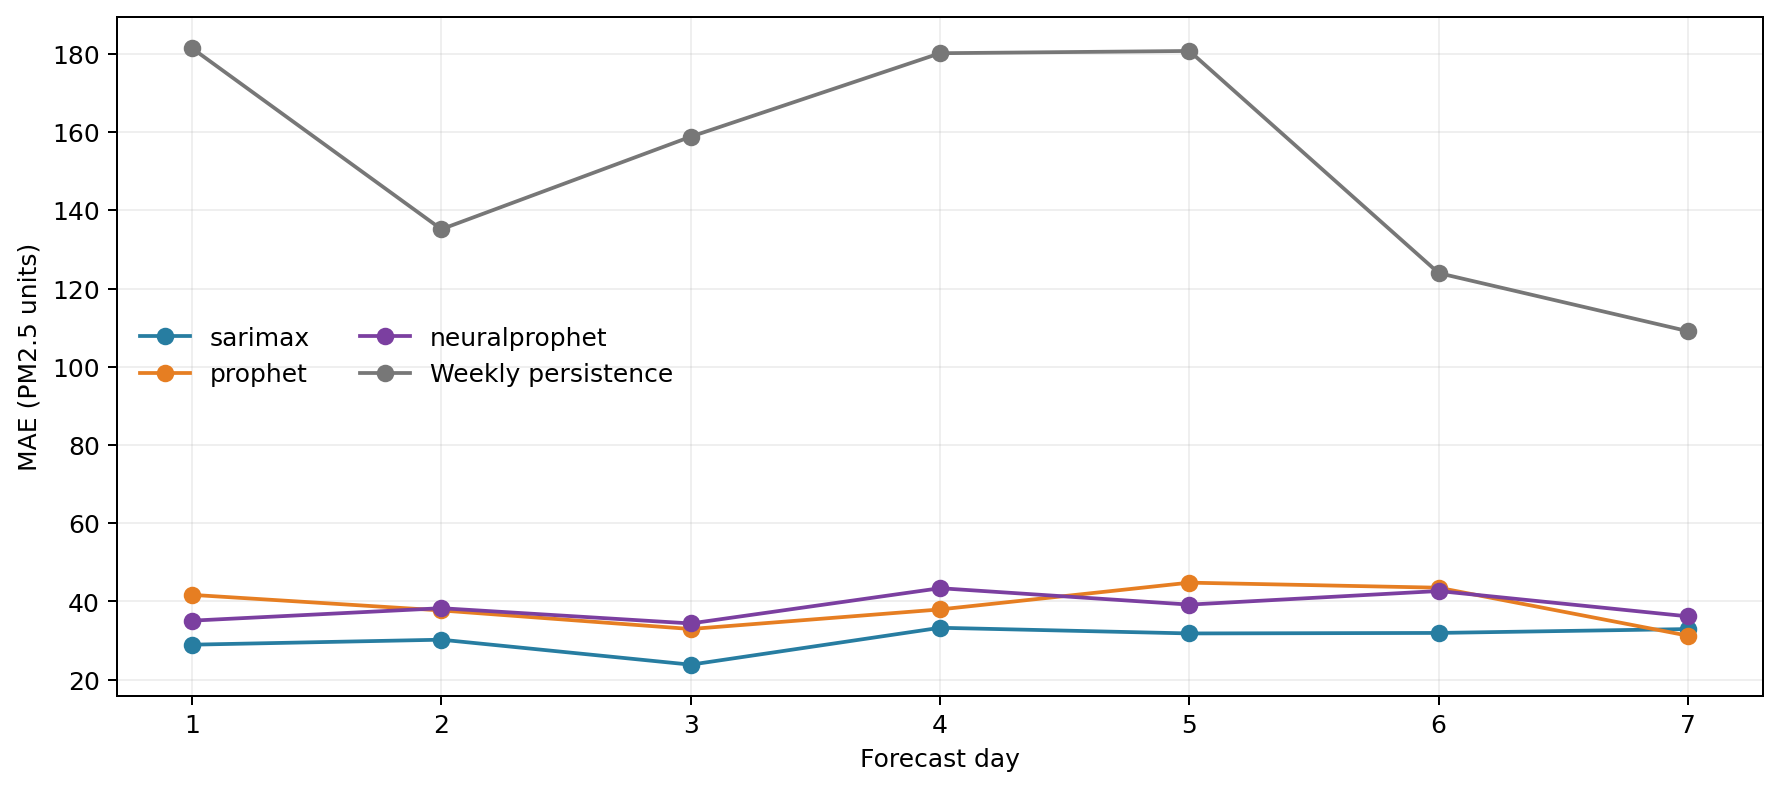

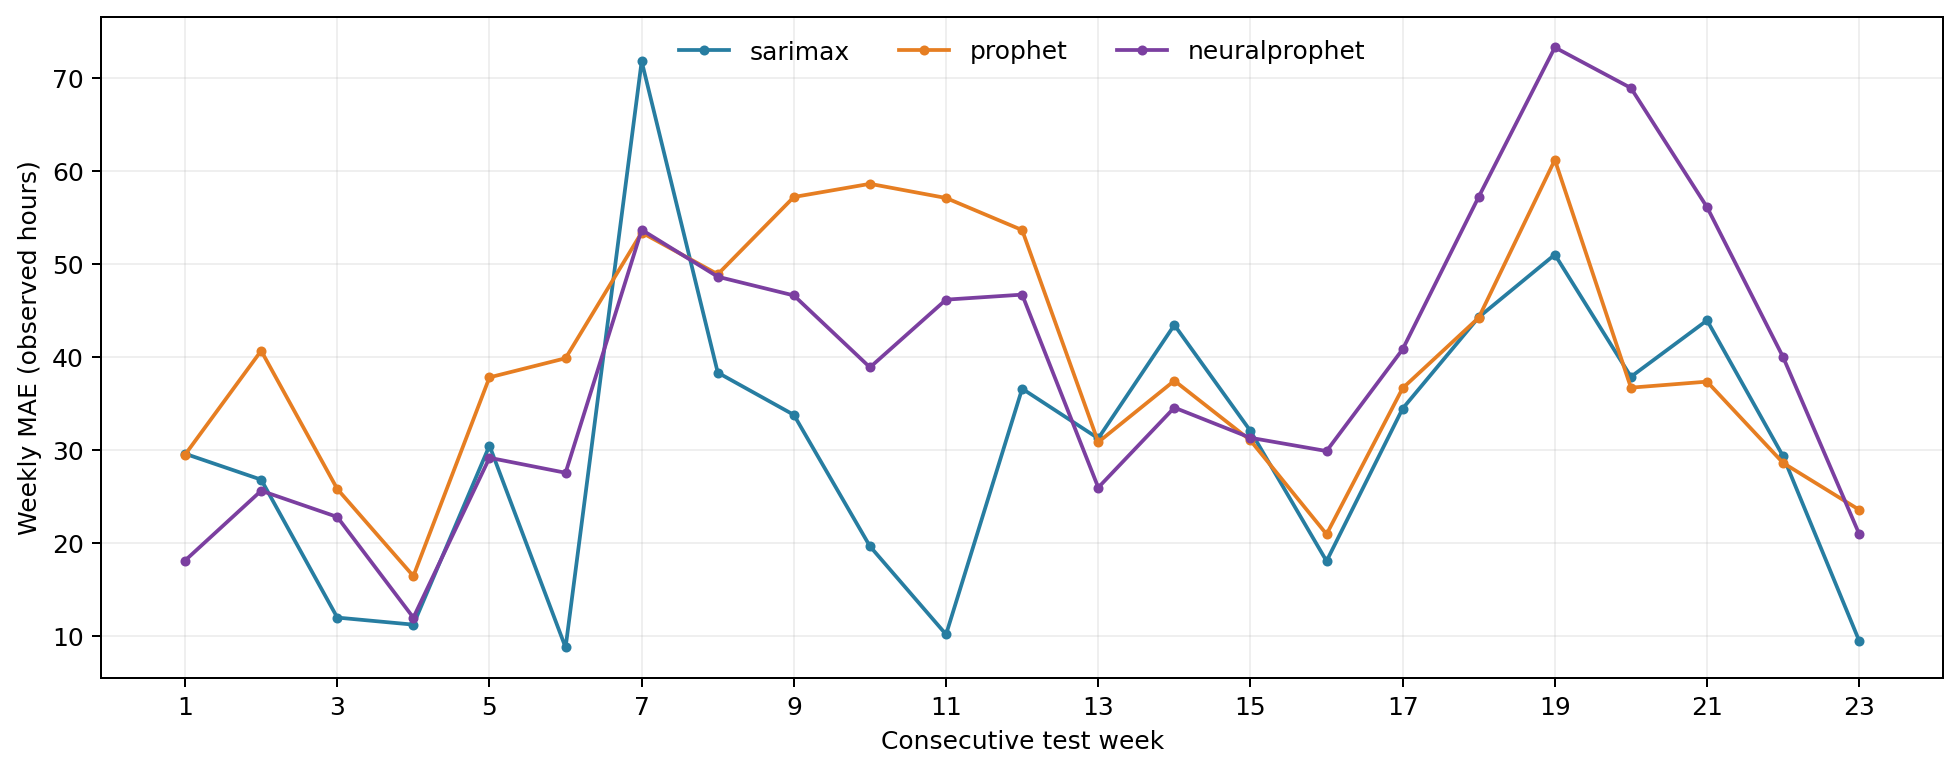

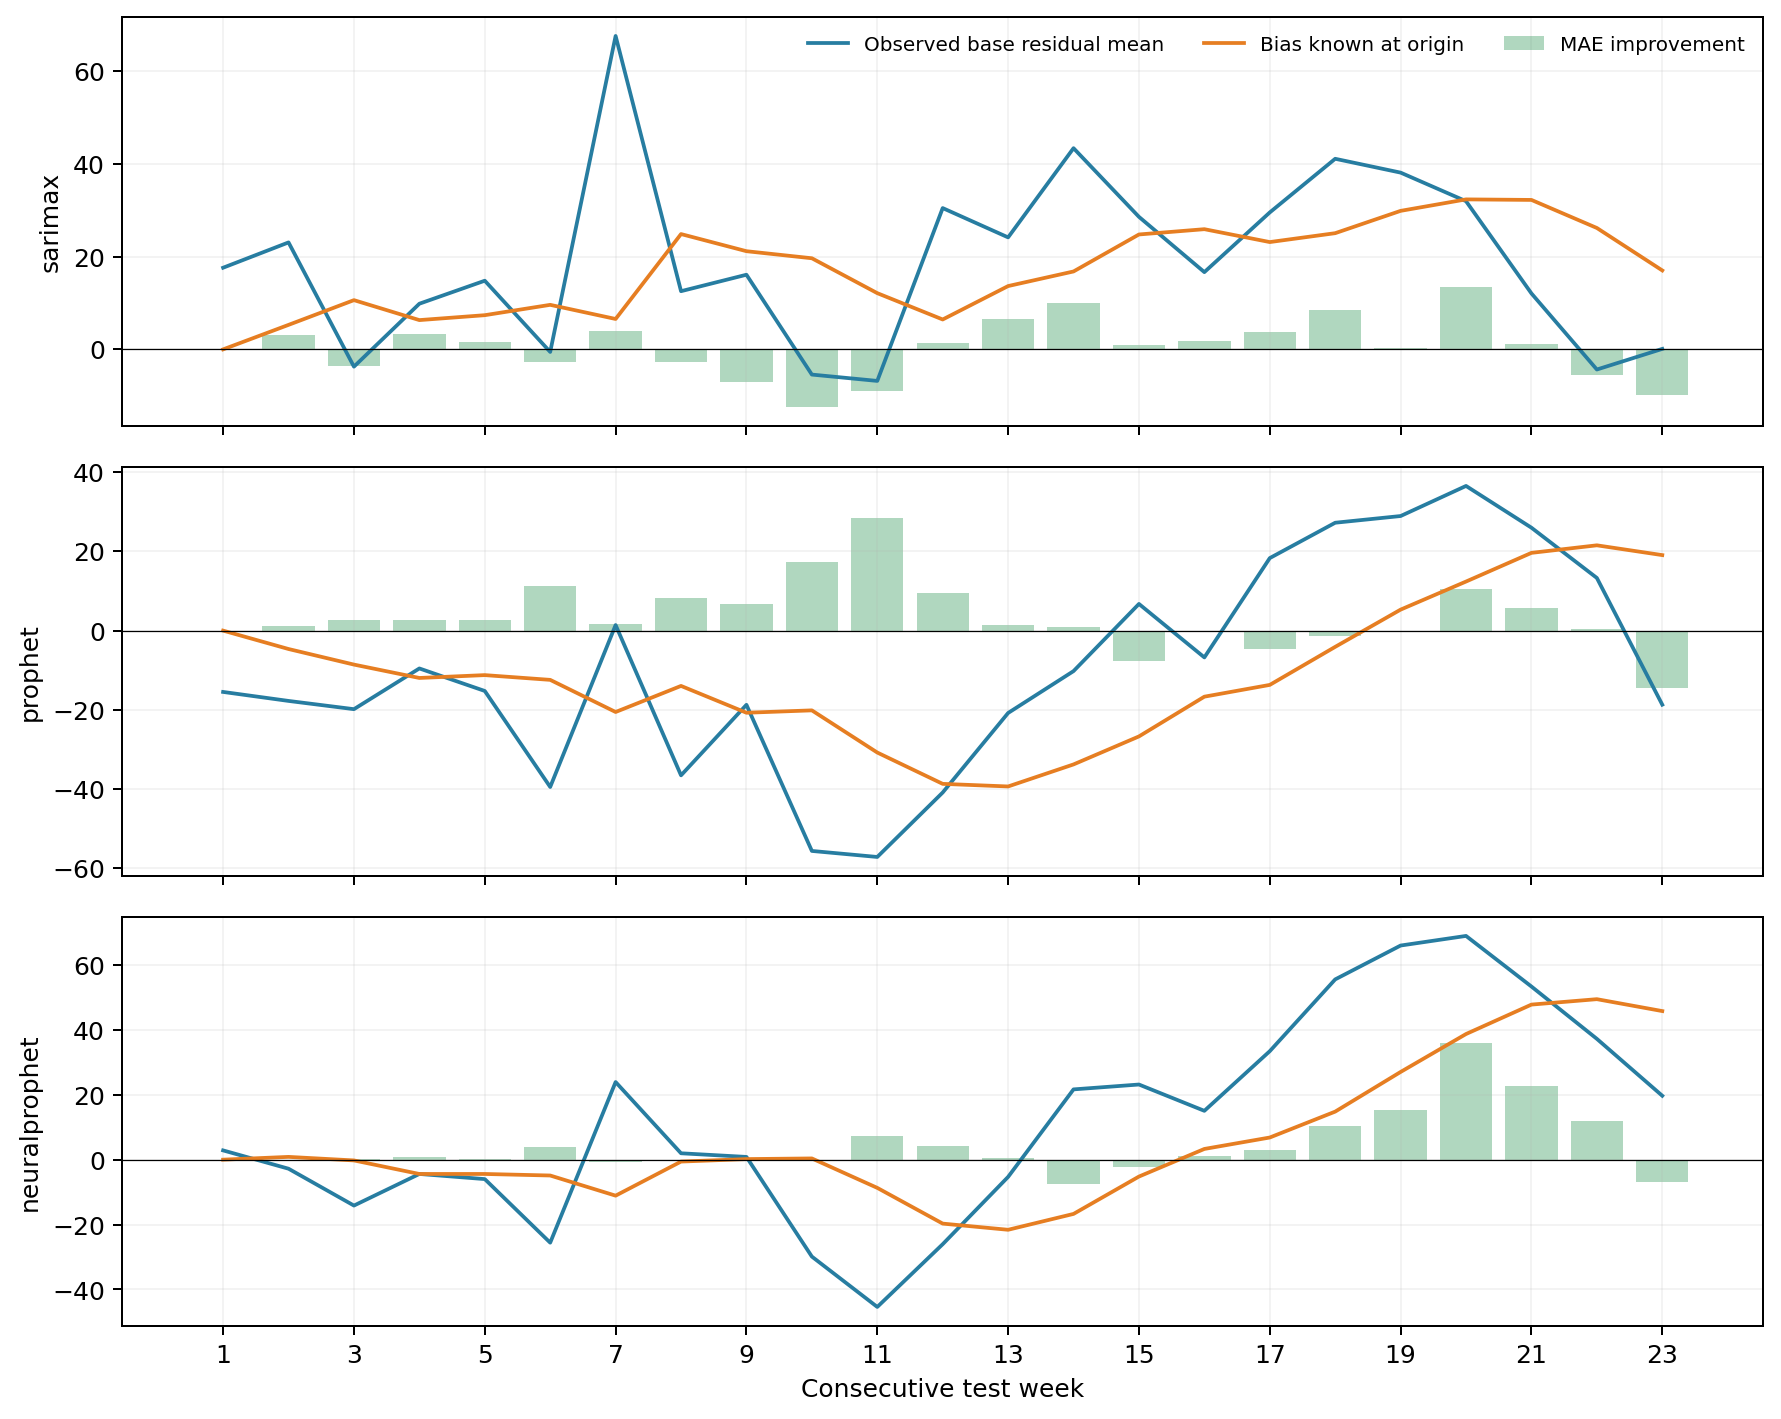

In [18]:
display(pd.read_csv(phase3 / "correction_alpha_summary.csv").query("alpha == 0.3"))
display(pd.read_csv(phase3 / "target_descriptive.csv"))
display(pd.read_csv(phase3 / "strict_sensitivity.csv").query("stream in ['sarimax_frozen_s42', 'prophet_frozen_s42', 'neuralprophet_frozen_s42']"))
for name in ["lead_day_mae", "weekly_mae_chronology", "correction_diagnostics"]:
    display(Image(filename=str(phase3 / "figures" / f"{name}.png"), width=850))


The full generated results report is `reports/PHASE3_RESULTS.md`; the point-by-point evidence map is `reports/PHASE3_FINDINGS_LEDGER.md`. Phase 4 will update the manuscript and response. The broader protocol uses causal filling only for missing historical inference context. Missing target hours are never scored, and future PP covariates remain an idealized information assumption.
